In [47]:
import cv2
from insightface.app import FaceAnalysis
import torch

import os
import sys
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../../external/IP-Adapter'))
from constants import BASE_DIR
from utils import show_images
from tqdm.auto import tqdm

In [2]:
app = FaceAnalysis(name="buffalo_l", providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(545, 545))

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'fuse_conv_bias': '0', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
find model: /home/aliaagheis/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvide

In [3]:
image_paths  = list((BASE_DIR / "datasets/celebrities/mo_salah/faces").glob("*.[jp][pn]*g"))
images = [cv2.imread(path) for path in image_paths]
faces = [app.get(image) for image in images]
faceid_embeds = [torch.from_numpy(face[0].normed_embedding).unsqueeze(0).unsqueeze(0)
                    for face in faces if len(face) > 0]
faceid_embeds = torch.cat(faceid_embeds, dim=1)

In [4]:
import torch
from diffusers import StableDiffusionPipeline, DDIMScheduler, AutoencoderKL
from PIL import Image

from ip_adapter.ip_adapter_faceid_separate import IPAdapterFaceID

2025-06-14 11:02:54.559020: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-14 11:02:54.698159: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-14 11:02:54.730205: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-14 11:02:56.685135: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [5]:
base_model_path = "SG161222/Realistic_Vision_V4.0_noVAE"
vae_model_path = "stabilityai/sd-vae-ft-mse"
ip_ckpt = BASE_DIR / "models/ip_adapter/ip-adapter-faceid-portrait_sd15.bin"
device = "cuda"


noise_scheduler = DDIMScheduler(
    num_train_timesteps=1000,
    beta_start=0.00085,
    beta_end=0.012,
    beta_schedule="scaled_linear",
    clip_sample=False,
    set_alpha_to_one=False,
    steps_offset=1,
)

vae = AutoencoderKL.from_pretrained(vae_model_path).to(dtype=torch.float16)
pipe = StableDiffusionPipeline.from_pretrained(
    base_model_path,
    torch_dtype=torch.float16,
    scheduler=noise_scheduler,
    vae=vae,
    feature_extractor=None,
    safety_checker=None
)


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

In [6]:
ip_model = IPAdapterFaceID(pipe, ip_ckpt, device, num_tokens=16, n_cond=16)

/home/aliaagheis/projects/Ad-Image-Generation/external/IP-Adapter/ip_adapter/ip_adapter_faceid_separate.py:174: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = to

In [ ]:
# generate image
prompt = "photorealistic"
negative_prompt = "deformed iris, deformed pupils, semi-realistic, cgi, 3d, render, sketch, cartoon, drawing, anime:1.4, text, close up, cropped, out of frame, worst quality, low quality, jpeg artifacts, ugly, duplicate, morbid, mutilated, extra fingers, mutated hands, poorly drawn hands, poorly drawn face, mutation, deformed, blurry, dehydrated, bad anatomy, bad proportions, extra limbs, cloned face, disfigured, gross proportions, malformed limbs, missing arms, missing legs, extra arms, extra legs, fused fingers, too many fingers, long neck"

images = ip_model.generate(
    prompt=prompt, negative_prompt=negative_prompt, faceid_embeds=faceid_embeds, num_samples=1, width=512, height=512, num_inference_steps=30, seed=2023
)

  0%|          | 0/30 [00:00<?, ?it/s]

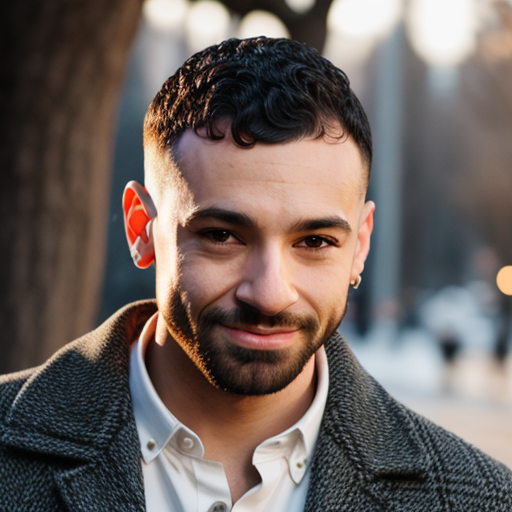

In [25]:
images[0]

  0%|          | 0/30 [00:00<?, ?it/s]

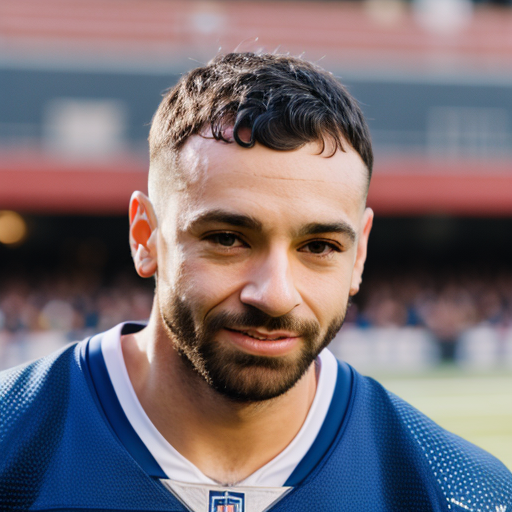

In [26]:
# generate image
prompt = "a football player"
negative_prompt = "deformed iris, deformed pupils, semi-realistic, cgi, 3d, render, sketch, cartoon, drawing, anime:1.4, text, close up, cropped, out of frame, worst quality, low quality, jpeg artifacts, ugly, duplicate, morbid, mutilated, extra fingers, mutated hands, poorly drawn hands, poorly drawn face, mutation, deformed, blurry, dehydrated, bad anatomy, bad proportions, extra limbs, cloned face, disfigured, gross proportions, malformed limbs, missing arms, missing legs, extra arms, extra legs, fused fingers, too many fingers, long neck"

images = ip_model.generate(
    prompt=prompt, negative_prompt=negative_prompt, faceid_embeds=faceid_embeds, num_samples=1, width=512, height=512, num_inference_steps=30, seed=2023
)

images[0]

  0%|          | 0/30 [00:00<?, ?it/s]

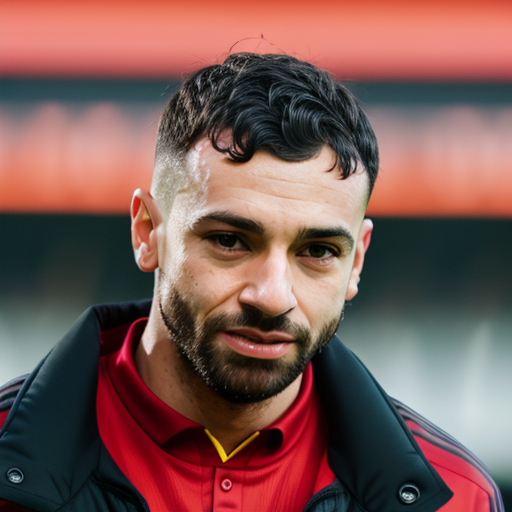

In [38]:
prompt = "best quality, high quality, angry liverpool football player"
negative_prompt = "deformed iris, deformed pupils, semi-realistic, cgi, 3d, render, sketch, cartoon, drawing, anime:1.4, text, close up, cropped, out of frame, worst quality, low quality, jpeg artifacts, ugly, duplicate, morbid, mutilated, extra fingers, mutated hands, poorly drawn hands, poorly drawn face, mutation, deformed, blurry, dehydrated, bad anatomy, bad proportions, extra limbs, cloned face, disfigured, gross proportions, malformed limbs, missing arms, missing legs, extra arms, extra legs, fused fingers, too many fingers, long neck"

images = ip_model.generate(
    prompt=prompt, negative_prompt=negative_prompt, faceid_embeds=faceid_embeds, num_samples=1, width=512, height=512, num_inference_steps=30, seed=2023
)

images[0]

# Inside Call

In [40]:
prompt = "best quality, high quality, angry liverpool football player"
negative_prompt = "deformed iris, deformed pupils, semi-realistic, cgi, 3d, render, sketch, cartoon, drawing, anime:1.4, text, close up, cropped, out of frame, worst quality, low quality, jpeg artifacts, ugly, duplicate, morbid, mutilated, extra fingers, mutated hands, poorly drawn hands, poorly drawn face, mutation, deformed, blurry, dehydrated, bad anatomy, bad proportions, extra limbs, cloned face, disfigured, gross proportions, malformed limbs, missing arms, missing legs, extra arms, extra legs, fused fingers, too many fingers, long neck"
num_inference_steps = 30
guidance_scale = 7.5
seed  = 42
# 1. get face image embeddings
image_prompt_embeds, uncond_image_prompt_embeds = ip_model.get_image_embeds(faceid_embeds)

# 2. get text embeddings
with torch.inference_mode():
    prompt_embeds_, negative_prompt_embeds_ = pipe.encode_prompt(
        prompt,
        device=device,
        num_images_per_prompt=1,
        do_classifier_free_guidance=True,
        negative_prompt=negative_prompt,
    )
    prompt_embeds = torch.cat([prompt_embeds_, image_prompt_embeds], dim=1)
    negative_prompt_embeds = torch.cat([negative_prompt_embeds_, uncond_image_prompt_embeds], dim=1)

generator = torch.Generator(device).manual_seed(seed)

images = pipe(
            prompt_embeds=prompt_embeds,
            negative_prompt_embeds=negative_prompt_embeds,
            guidance_scale=guidance_scale,
            num_inference_steps=num_inference_steps,
            generator=generator,
            num_images_per_prompt=1,
        ).images

  0%|          | 0/30 [00:00<?, ?it/s]

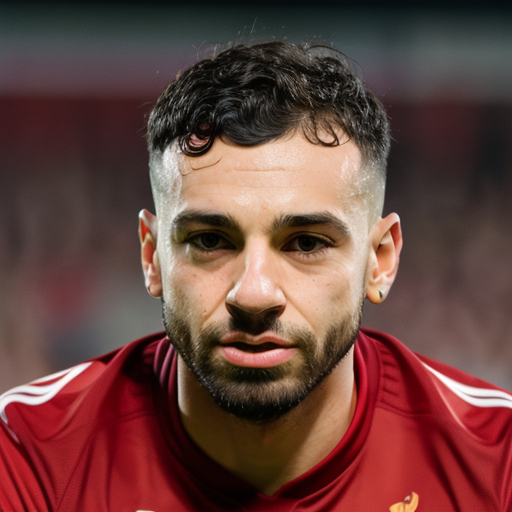

In [41]:
images[0]

# Denoising loop

In [ ]:
prompt = "best quality, high quality, angry liverpool football player"
negative_prompt = "deformed iris, deformed pupils, semi-realistic, cgi, 3d, render, sketch, cartoon, drawing, anime:1.4, text, close up, cropped, out of frame, worst quality, low quality, jpeg artifacts, ugly, duplicate, morbid, mutilated, extra fingers, mutated hands, poorly drawn hands, poorly drawn face, mutation, deformed, blurry, dehydrated, bad anatomy, bad proportions, extra limbs, cloned face, disfigured, gross proportions, malformed limbs, missing arms, missing legs, extra arms, extra legs, fused fingers, too many fingers, long neck"
num_inference_steps = 30
guidance_scale = 7.5
seed  = 42
image_size = (512, 512)
# 1. get face image embeddings
image_prompt_embeds, uncond_image_prompt_embeds = ip_model.get_image_embeds(faceid_embeds)

# 2. get text embeddings
with torch.inference_mode():
    prompt_embeds_, negative_prompt_embeds_ = pipe.encode_prompt(
        prompt,
        device=device,
        num_images_per_prompt=1,
        do_classifier_free_guidance=True,
        negative_prompt=negative_prompt,
    )
    prompt_embeds = torch.cat([prompt_embeds_, image_prompt_embeds], dim=1)
    negative_prompt_embeds = torch.cat([negative_prompt_embeds_, uncond_image_prompt_embeds], dim=1)


  0%|          | 0/30 [00:00<?, ?it/s]

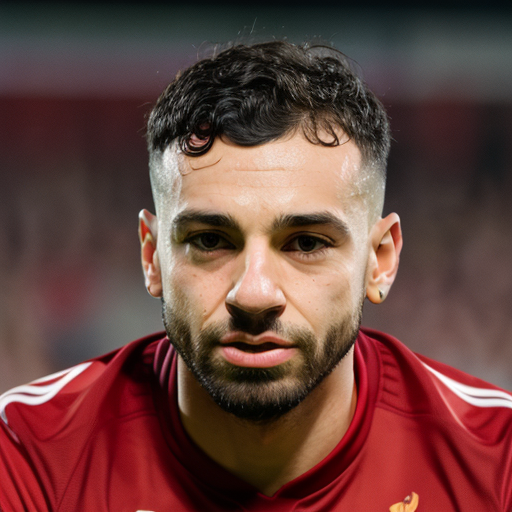

In [ ]:
nsamples = 1
dtype = torch.float16
latent_size = (image_size[0] // 8, image_size[1] // 8)
generator = torch.Generator(device).manual_seed(seed)

# 3. prepare noisy latents, embeddings
noise_scheduler.set_timesteps(num_inference_steps)
latents = torch.randn((nsamples, pipe.unet.config.in_channels, latent_size[0], latent_size[1] ), dtype=dtype, device=device, generator=generator)
embeddings = torch.cat([
                        prompt_embeds.repeat(nsamples, 1, 1), 
                        negative_prompt_embeds.repeat(nsamples, 1, 1)
])
# denoising loop
for i, t in enumerate(tqdm(noise_scheduler.timesteps)):
    latents_in = torch.cat([latents] * 2)
    with torch.no_grad():
        noise_pred = pipe.unet(latents_in, t, encoder_hidden_states=embeddings).sample
        
    noise_pos, noise_neg = noise_pred.chunk(2)
    noise_pred = noise_neg + guidance_scale * (noise_pos - noise_neg)
    latents = noise_scheduler.step(noise_pred, t, latents).prev_sample
# decode vae    
latents /= vae.config.scaling_factor
with torch.no_grad():
    image = vae.decode(latents, generator=generator).sample
# show output
show_images(image)

# Img2Img Loop

In [56]:
prompt = "best quality, high quality, angry liverpool football player"
negative_prompt = "deformed iris, deformed pupils, semi-realistic, cgi, 3d, render, sketch, cartoon, drawing, anime:1.4, text, close up, cropped, out of frame, worst quality, low quality, jpeg artifacts, ugly, duplicate, morbid, mutilated, extra fingers, mutated hands, poorly drawn hands, poorly drawn face, mutation, deformed, blurry, dehydrated, bad anatomy, bad proportions, extra limbs, cloned face, disfigured, gross proportions, malformed limbs, missing arms, missing legs, extra arms, extra legs, fused fingers, too many fingers, long neck"
num_inference_steps = 30
guidance_scale = 7.5
seed  = 42
image_size = (512, 512)
# 1. get face image embeddings
image_prompt_embeds, uncond_image_prompt_embeds = ip_model.get_image_embeds(faceid_embeds)

# 2. get text embeddings
with torch.inference_mode():
    prompt_embeds_, negative_prompt_embeds_ = pipe.encode_prompt(
        prompt,
        device=device,
        num_images_per_prompt=1,
        do_classifier_free_guidance=True,
        negative_prompt=negative_prompt,
    )
    prompt_embeds = torch.cat([prompt_embeds_, image_prompt_embeds], dim=1)
    negative_prompt_embeds = torch.cat([negative_prompt_embeds_, uncond_image_prompt_embeds], dim=1)
